# 202235203 고수호
# **5week - diabetes.csv 데이터에 대한 DL_Regression**

# **# 라이브러리 임포트**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

# **# 데이터 세트 불러오기**

In [2]:
path = '/content/drive/MyDrive/Colab Notebooks/5week/diabetes.csv'
df = pd.read_csv(path)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# **# Feature Selection을 위한 상관관계 확인**

<Axes: >

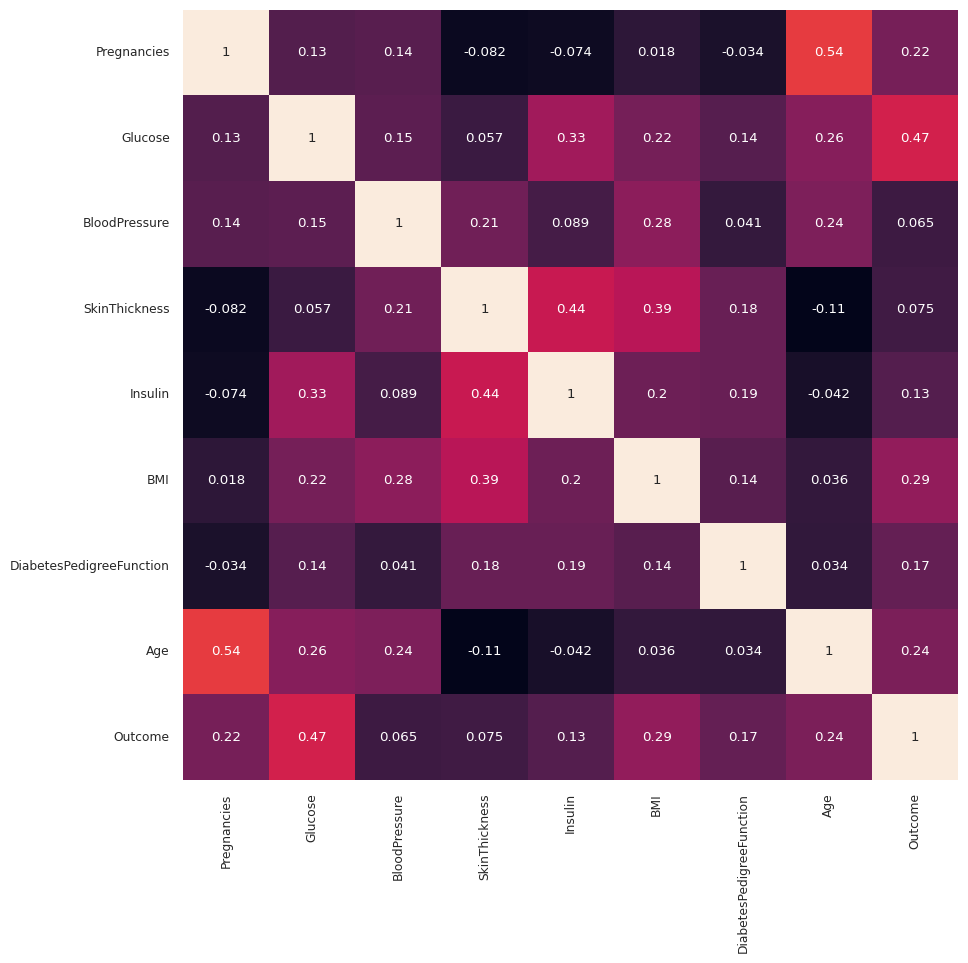

In [3]:
df_corr = df.corr()
plt.figure(figsize=(10,10))
sns.set(font_scale = 0.8)
sns.heatmap(df_corr, annot=True, cbar=False)

# **# 결측치 확인**

In [4]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


# **# 종속변수(y) 설정**

In [5]:
y=df['BMI']
y.value_counts()

,count
BMI,
32.0,13
31.6,12
31.2,12
0.0,11
32.4,10
...,...
49.6,1
24.1,1
41.2,1


# **# 원-핫 인코딩**

In [6]:
Y = pd.get_dummies(y).values

# **# 독립변수(X) 설정 및 Feature Selection**

In [7]:
X=df.drop(['Outcome', 'Pregnancies'], axis=1)
X.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,148,72,35,0,33.6,0.627,50
1,85,66,29,0,26.6,0.351,31
2,183,64,0,0,23.3,0.672,32
3,89,66,23,94,28.1,0.167,21
4,137,40,35,168,43.1,2.288,33


# **# 딥러닝 입력을 위해 Numpy 배열로 변환**

In [8]:
X = X.values

# **# 데이터셋 분리 (Training & Test Set)**

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

# **# 딥러닝 모델 구성 및 학습**

```python
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

model = Sequential()
```
* **Sequential** : 레이어 순차적 적재. 모델 컨테이너 역할.
* **SGD, Adam** : 최적화 라이브러리 임포트.

```python
model.add(Dense(8,input_shape=(X.shape[1],),activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(1))
```
* **Dense(8, input_shape=(X.shape[1],), activation='relu')** : 첫 번째 은닉층. 노드 8개. 입력 특성 10개 정의. ReLU 활성화 함수 적용.
* **Dense(30, activation='relu')** : 추가 은닉층. 노드 30개 확장. 복잡한 데이터 패턴 학습.
* **Dense(1)** : 출력층. 노드 1개. 활성화 함수 미지정으로 수치 예측(회귀) 수행.

```python
model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mse'])
```
* **adam** : 최적화 알고리즘.
* **mse (Mean Squared Error)** : 손실 함수 및 평가지표. 실제값과 예측값 차이의 제곱 평균 계산.

```python
model.summary()
```
* **model.summary()** : 모델 구조 출력. 레이어별 파라미터 수 및 출력 크기 확인.



In [10]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam


model = Sequential()

model.add(Dense(8,input_shape=(X.shape[1],),activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(1))

model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mse'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,295 (5.06 KB)

 Trainable params: 1,295 (5.06 KB)

 Non-trainable params: 0 (0.00 B)

# **# 모델 학습 및 예측**

```python
N_EPOCHS = 50
history = model.fit(
    X_train, y_train,
    epochs=N_EPOCHS,
    batch_size=32,
    validation_data= (X_test,y_test))
```
* **N_EPOCHS = 50** : 전체 학습 데이터 반복 횟수 설정. 50회 실시.
* **model.fit** : 모델 학습 실행 함수. 훈련 데이터($X\_train, y\_train$)를 기반으로 가중치 업데이트.
* **epochs=N_EPOCHS** : 학습 반복 횟수를 50으로 적용.
* **batch_size=32** : 가중치 갱신을 위해 한 번에 처리할 데이터 묶음 크기 설정.
* **validation_data=(X_test, y_test)** : 매 에포크 종료 후 검증 데이터를 사용해 모델 성능 모니터링.

```python
y_pred = model.predict(X_test)
```
* **model.predict(X_test)** : 학습된 모델에 테스트 데이터를 입력하여 결과값 예측.
* **y_pred** : 모델이 예측한 수치 데이터를 변수에 저장. 실제값과 비교하여 성능 평가에 활용.

In [14]:
N_EPOCHS = 50

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0695 - mse: 0.0695 - val_loss: 0.0919 - val_mse: 0.0919
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0697 - mse: 0.0697 - val_loss: 0.0836 - val_mse: 0.0836
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0649 - mse: 0.0649 - val_loss: 0.0827 - val_mse: 0.0827
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0613 - mse: 0.0613 - val_loss: 0.0836 - val_mse: 0.0836
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0628 - mse: 0.0628 - val_loss: 0.0795 - val_mse: 0.0795
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0601 - mse: 0.0601 - val_loss: 0.0783 - val_mse: 0.0783
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0586 - mse: 0.0586 - val_loss: 0.0790 - val_mse: 0.0790
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0542 - mse: 0.0542 - val_loss: 0.0796 - val_mse: 0.0796
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0607 -

# **# 손실 지표 시각화**

```python
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
```
* **import matplotlib.pyplot as plt** : 데이터 시각화를 위한 라이브러리 호출.
* **plt.figure(figsize=(10,7))** : 그래프 크기 설정. 가로 10, 세로 7 인치로 지정.

```python
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
```
* **range(N_EPOCHS)** : x축 범위 설정.
* **history.history['loss']** : 학습 데이터의 손실값 변화량 시각화.
* **history.history['val_loss']** : 검증 데이터의 손실값 변화량 시각화.
* **label** : 각 선의 식별 이름 부여. 'train loss' 및 'test loss'로 설정.

```python
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
```
* **plt.xlabel / ylabel** : 각 축의 레이블 설정. x축은 에포크, y축은 손실값.
* **plt.legend()** : 그래프 내 범례 표시. 설정한 레이블 출력.
* **plt.show()** : 최종 그래프 화면 출력. 학습 추이 및 과적합 여부 판단 근거.

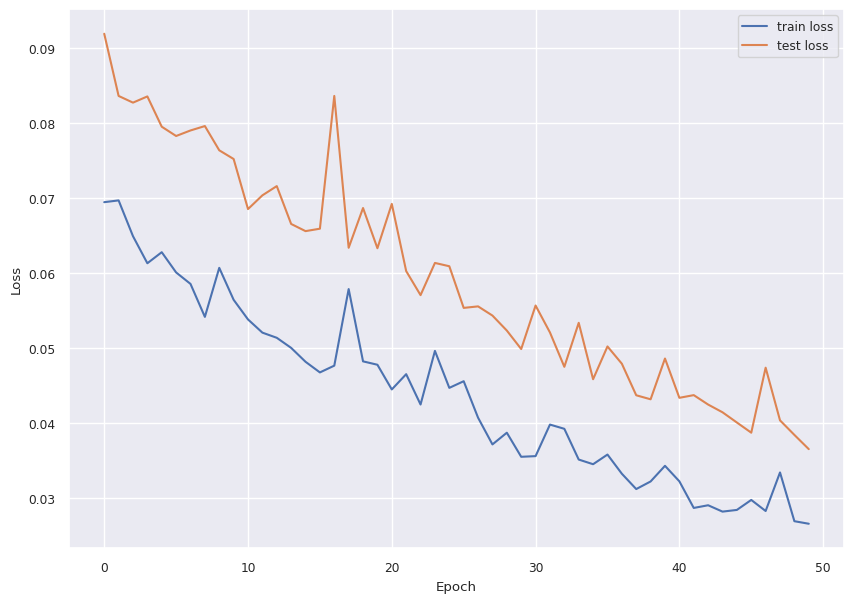

In [15]:
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# **# 모델 평가 수행**

```python
model.evaluate(X_test, y_test)
```
* **model.evaluate** : 검증 데이터셋을 사용한 최종 모델 성능 측정 함수.
* **X_test, y_test** : 학습에 사용되지 않은 별도의 테스트 데이터와 정답지 입력.
* **출력값** : 컴파일 단계에서 설정한 손실값(Loss)과 평가지표(MSE 등) 계산 및 반환. 학습 결과의 객관적 성능 확인.

In [16]:
model.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0365 - mse: 0.0365


[0.036526862531900406, 0.036526862531900406]